In [1]:
import torch

In [2]:
from importlib.metadata import version
pkgs=[
    "matplotlib",
    "numpy",
    "tiktoken",
    "torch",
    "tensorflow"
]

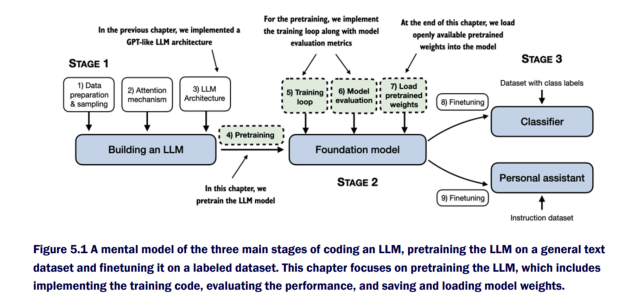

In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("5.1.png")

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

##### in the previous chapters, we implemented the data sampling, attention mechanism and coded the LLM architecture. The core focus of this chapter is to implement a training function and pretrain the LLM, as illustrated in Figure 5.1.

##### as illustrated in Figure 5.1, we will also learn about basic model evaluation techniques to measure the quality of the generated text, which is a requirement for optimizing the LLM during the training process. Moreover, we will discuss how to load pretrained weights,giving our LLM a solid starting point for finetuning in the upcoming chapte

##### WEIGHT PARAMETERS -> In the context of LLMs and other deep learning models, weights refer to the trainable parameters that the learning process adjusts. These weights are also known as weight parameters or simply parameters. In frameworks like PyTorch, these weights are stored in linear layers, for example, which we used to implement the multi-head attention module in chapter 3 and the GPTModel in chapter 4. After initializing a layer(new_layer = torch.nn.Linear(...)), we can access its weights through the .weight attribute, new_layer.weight. Additionally, for convenience, PyTorch allowsdirect access to all a model's trainable parameters, including weights and biases, through the method model.parameters(), which we will use later when implementing the model training.

### 5.1 Evaluating generative text models

##### We begin this chapter by setting up the LLM for text generation based on code from the previous chapter and discuss basic ways to evaluate the quality of the generated text in this section.

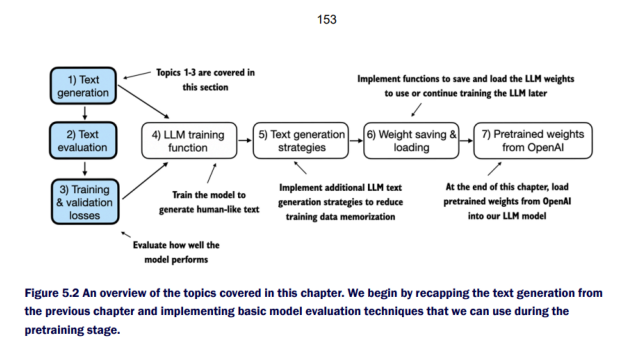

In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("5.2.png")

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

##### the next subsection recaps the text generation we set up at the end of the previous chapter before we dive into the text evaluation and calculation of the training and validation losses in the subsequent subsection

### 5.1.1 Using GPT to generate text

##### we set up the LLM and briefly recap the text generation process we implemented in previous chapter. we begin by initializing the GPT model that we will evaluate and train in this chapter, using the GPTModel class and GPT_CONFIG_124M dictionary from gpt arch chapter.

##### please note: the components.py in this chapter is the updated version of the components.py used in previous chapter, now it has all the other compoents that are require to run the gptmodel here

In [5]:
from components import GPTModel

In [6]:
GPT_CONFIG_124M = {
"vocab_size": 50257,
"context_length": 256, # We shorten the context length from 1024 to 256 tokens
"emb_dim": 768,
"n_heads": 12,
"n_layers": 12,
"drop_rate": 0.1, #
"qkv_bias": False
}


##### instantiate the gpt model

In [7]:
torch.manual_seed(123)
model=GPTModel(GPT_CONFIG_124M)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm()
      (att): MaskedMultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (dropout): Dropout(p=0.1, inplace=False)
        (output_proj): Linear(in_features=768, out_features=768, bias=True)
      )
      (norm2): LayerNorm()
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (dropout_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (norm1): LayerNorm()
      (att): MaskedMultiHeadAtt

##### using the GPTmodel instance, we adopt the generate_text_simple function introduced  in the previous chapter and introduce two handy functions, text_to_token_ids and token_ids_to_text. these functions facilitate the conversion between text and token representations

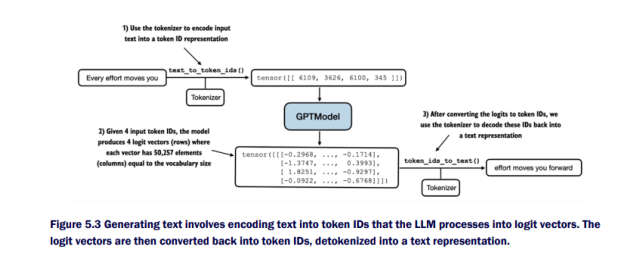

In [8]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("5.3.png")

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

##### First, the tokenizer converts input text into a series of token IDs. Second, the model receives these token IDs and generates corresponding logits, which are vectors representing the probability distribution for each token in the vocabulary. third, these logits are converted back into token IDs, which the tokenizer decodes into human-readable text, completing the cycle from textual input to textualoutput.

##### utility functions for text to token ID conversion

In [9]:
import tiktoken
from components import generate_text_simple

def text_to_token_ids(text,tokenizer):
    encoded=tokenizer.encode(text,allowed_special={'<|endoftext|>'})
    encoded_tensor=torch.tensor(encoded).unsqueeze(0) #we convert the list above to pytorch tensor cause the model expects tensor(adds batch dimension)
    return encoded_tensor

def token_ids_to_text(token_ids,tokenizer):
    flat=token_ids.squeeze(0) 
    return tokenizer.decode(flat.tolist()) #needs a normal Python list.

start_context="Every effort moves you"
tokenizer=tiktoken.get_encoding("gpt2")

token_ids=generate_text_simple(
    model=model,
    input_tokens=text_to_token_ids(start_context,tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("output  text:\n ",token_ids_to_text(token_ids,tokenizer))


 ******************1 ****************


 input sent to the model
tensor([[6109, 3626, 6100,  345]])
torch.Size([1, 4])

 model output shape: 
torch.Size([1, 4, 50257])

 last position logits: 
torch.Size([1, 50257])

 probabilites vector:
torch.Size([1, 50257])

 predicted token id
tensor([[34245]])

 sequence after appending
tensor([[ 6109,  3626,  6100,   345, 34245]])
new_shape: torch.Size([1, 5])

 ******************2 ****************


 input sent to the model
tensor([[ 6109,  3626,  6100,   345, 34245]])
torch.Size([1, 5])

 model output shape: 
torch.Size([1, 5, 50257])

 last position logits: 
torch.Size([1, 50257])

 probabilites vector:
torch.Size([1, 50257])

 predicted token id
tensor([[5139]])

 sequence after appending
tensor([[ 6109,  3626,  6100,   345, 34245,  5139]])
new_shape: torch.Size([1, 6])

 ******************3 ****************


 input sent to the model
tensor([[ 6109,  3626,  6100,   345, 34245,  5139]])
torch.Size([1, 6])

 model output shape: 
torch.Size([

##### it's clear the model isn't yet producing coherent text because it hasn't undergone training.

##### To define what makes text "coherent" or "high quality," we have to implement a numerical method to evaluate the generated content. This approach will enable us to monitor and enhance the model's performance throughout its training process.

##### the following section introduces how we calculate a loss metric for the generated outputs. This loss serves as a progress and success indicator of the training progress. Furthermore, in subsequent chapters on finetuning LLMs, we will review additional methodologies for assessing model quality.

### 5.1.2 Calculating the text generation loss : cross entropy and perplexity

##### now , we explore techniques for numerically assessing text quality generated during training by calculating a so-called text generation loss. We go over this topic step-by-step with a practical example to make the concepts clear and applicable, beginning with a short recap of how the data is loaded from chapter 2 and how the text is generated via the generate_text_simple function from chapter 4

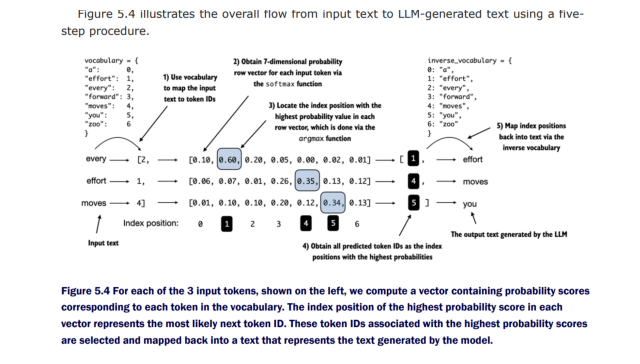

In [10]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("5.4.png")

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

##### The text generation process in Figure 5.4 outlines what the generate_text_simple function from chapter 4 does internally. We need to perform these same initial steps before we can compute a loss that measures the generated text quality later in this section. Figure 5.4 outlines the text generation process with a small 7-token vocabulary to fit this image on a single page. However, our GPTModel works with a much larger vocabulary consisting of 50,257 words; hence, the token IDs in the following codes will range from 0 to 50,256 rather than 0 to 6.


##### Also, Figure 5.4 only shows a single text example ("every effort moves") for simplicity. In the following hands-on code example that implements the steps in Figure 5.4, we will work with two input examples ("every effort moves" and "I really like") as inputs for the GPT model: Consider the two input examples, which have already been mapped to token IDs,corresponding to step 1 in Figure 5.4:

In [11]:
inputs=torch.tensor([[16833, 3626, 6100],   #["Every effort moves,
                    [40, 1107, 588]]) #        I really like"]
#matching these inputs 'the target' contain the token ids we aim for the model to produce
targets = torch.tensor([[3626, 6100, 345 ], # [" effort moves you",
[107, 588, 11311]]) # " really like chocolate"]

##### targets are the inputs but shifted one position forward, a concept we covered chapter 2 during the implementation of the data loader. This shifting strategy is crucial for teaching the model to predict the next token in a sequence.


##### When we feed the inputs into the model to calculate logit vectors for the two input examples, each comprising three tokens, and apply the softmax function to transform these logit values into probability scores, which corresponds to step 2 in Figure 5.4:

In [12]:
with torch.no_grad(): #disable gradient tracking since we are not training, yet
    logits=model(inputs)
probas= torch.softmax(logits,dim=-1)
print(probas.shape)

torch.Size([2, 3, 50257])


##### the first number, 2, corresponds to the two examples (rows) in the inputs, also known as batch size. The second number, 3, corresponds to the number of tokens in each input(row). Finally, the last number corresponds to the embedding dimensionality, which is determined by the vocabulary size, as discussed in previous chapters.

##### following the conversion from logits to probabilities via the softmax function, the generate_text_simple function from chapter 4 then converts the resulting probability scores back into text, as illustrated in steps 3-5 in Figure 5.4

##### we can implement steps 3 and 4 by applying the argmax function to the probability scores to obtain the corresponding token IDs:

In [13]:
token_ids=torch.argmax(probas,dim=-1,keepdim=True)
print("token ids:\n", token_ids)
#here we are basically choosing tokens with highest probablites, each token choses 1, so since we have 2 sentence, ech with3 tokens, we will have 3 for first and3 for second inpt,all together 6 probab with higest value ie predicted token.

token ids:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


##### Finally, step 5 converts the token IDs back into text

In [14]:
print(f"target batch 1:{token_ids_to_text(targets[0],tokenizer)}")
print(f"output batch 1:{token_ids_to_text(token_ids[0].flatten(),tokenizer)}")

target batch 1: effort moves you
output batch 1: Armed heNetflix


##### what we did above was took the predicted tokens and convert both of them into the text to see what it predicted

##### The model produces random text that is different from the target text because it has not been trained yet.

##### we now evaluate the performance of the model's generated text numerically via a so-called loss as illustrated in Figure 5.4.  this is useful for measuring the quality of the generated text, but it's also a building block for implementing the training function later, which we use to update the model's weight to improve the generated tex

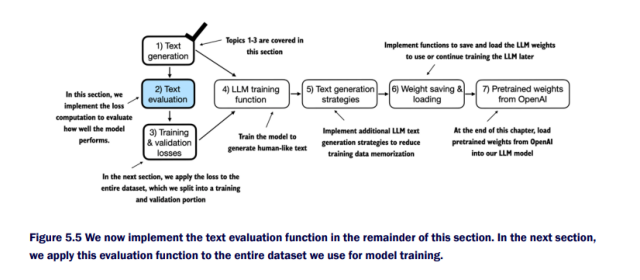

In [15]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("5.5.png")

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

##### part of the text evaluation process that we implement in the remainder of this section, as shown in Figure 5.5, is to measure "how far" the generated tokens are from the correct  predictions (targets). The training function we implement later in this chapter will use this information to adjust the model weights to generate text that is more similar to (or ideally matches) the target text

##### the model training aims to increase the softmax probability in the index positions corresponding to the correct target token IDs, as illustrated in Figure 5.6. This softmax probability is also used in the evaluation metric we are implementing in the remainder of this section to numerically assess the model's generated outputs: the higher the probability in the correct positions, the better.


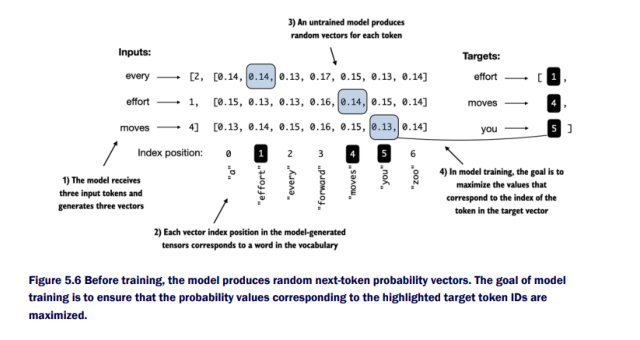

In [16]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("5.6.png")

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

#####  figure 5.6 displays the softmax probabilities for a compact 7-token vocabulary to fit everything into a single figure. This implies that the starting random values will hover around 1/7, which equals approximately 0.14.However, the vocabulary we are using for our GPT-2 model has 50,257 tokens, so most of the initial probabilities will hover around 0.00002 via 1/50,257.For each of the two input texts, we can print the initial softmax probability scorescorresponding to the target tokens via the following code:

In [17]:
probas

tensor([[[1.8849e-05, 1.5172e-05, 1.1687e-05,  ..., 2.2409e-05,
          6.9776e-06, 1.8776e-05],
         [9.1569e-06, 1.0062e-05, 7.8786e-06,  ..., 2.9090e-05,
          6.0103e-06, 1.3571e-05],
         [2.9877e-05, 8.8507e-06, 1.5741e-05,  ..., 3.5456e-05,
          1.4094e-05, 1.3526e-05]],

        [[1.2561e-05, 2.0537e-05, 1.4332e-05,  ..., 1.0389e-05,
          3.4784e-05, 1.4239e-05],
         [7.2731e-06, 1.7864e-05, 1.0565e-05,  ..., 2.1206e-05,
          1.1390e-05, 1.5559e-05],
         [2.9496e-05, 3.3605e-05, 4.1029e-05,  ..., 6.5249e-06,
          5.8203e-05, 1.3698e-05]]])

In [18]:
probas.shape

torch.Size([2, 3, 50257])

In [19]:
targets[0]

tensor([3626, 6100,  345])

In [20]:
text_idx=0
target_probas_1 =probas[text_idx,[0,1,2],targets[text_idx]]
print("text 1: " ,target_probas_1)

text_idx=1
target_probas_2 =probas[text_idx,[0,1,2],targets[text_idx]]
print("text 1: " ,target_probas_2)

text 1:  tensor([7.4540e-05, 3.1061e-05, 1.1563e-05])
text 1:  tensor([3.9108e-05, 5.6776e-05, 4.7559e-06])


##### the above selects each input text from the batch and retrieves the model's predicted probabilities for the correct target tokens at each prediction position. It checks how much probability the model gave to the actual next tokens for both texts. These values show how confident the model is in the correct predictions before training.


##### The goal of training an LLM is to maximize these values, aiming to get them as close to a probability of 1. This way, we ensure the LLM consistently picks the target token— essentially the next word in the sentence—as the next token it generates.


#####  we now calculate the loss for the probability scores of the two example batches, target_probas_1 and target_probas_2

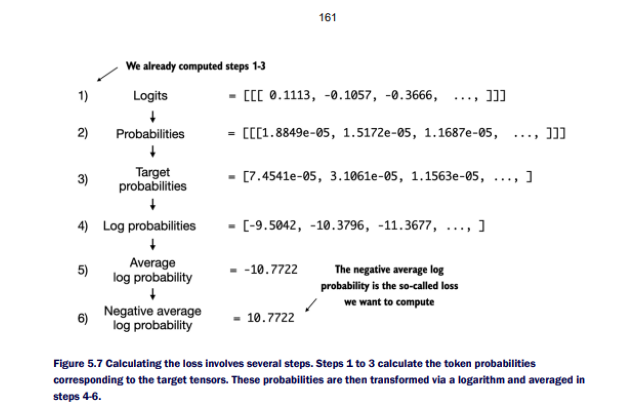

In [21]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("5.7.png")

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

##### since we already applied steps 1-3 listed in Figure 5.7 to obtain target_probas_1 and target_probas_2, we proceed with step 4, applying the logarithm to the probability scores:

In [22]:
log_probas=torch.log(torch.cat((target_probas_1,target_probas_2)))
print(log_probas)

tensor([ -9.5042, -10.3796, -11.3677, -10.1492,  -9.7764, -12.2561])


##### working with logarithms of probability scores is more manageable in mathematical optimization than handling the scores directly. This topic is outside the scope of this book,we combine these log probabilities into a single score by computing the average (step 5 in Figure 5.7):


In [23]:
avg_log_probas=torch.mean(log_probas)
print(avg_log_probas)

tensor(-10.5722)


##### The goal is to get the average log probability as close to 0 as possible by updating the model's weights as part of the training process

##### However, in deep learning, the common practice isn't to push the average log probability up to 0 but rather to bring the negative average log probability down to 0. The negative average log probability is simply the average log probability multiplied by -1, which corresponds to step 6 in Figure 5.7:


In [24]:
neg_avg_log_probas= avg_log_probas*-1
print(neg_avg_log_probas)

tensor(10.5722)


##### The term for this negative value, -10.7940 turning into 10.7940, is known as the cross entropy loss in deep learning.


##### pyTorch comes in handy here, as it already has a built-in cross_entropy function that takes care of all these 6 steps in Figure 5.7 for us

##### Before we apply the cross entropy function, briefly recall the shape of the logits andtarget tensors:

In [25]:
print("Logits shape:",logits.shape)
print("targets shape:" ,targets.shape)

Logits shape: torch.Size([2, 3, 50257])
targets shape: torch.Size([2, 3])


##### the logits tensor has three dimensions: batch size, number of tokens, and vocabulary size. The targets tensor has two dimensions: batch size and number of tokens. For the cross entropy_loss function in PyTorch, we want to flatten these tensors by combining them over the batch dimension:

In [26]:
logits_flat=logits.flatten(0,1)
targets_flat=targets.flatten(0,1)

In [27]:
print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


##### remember that the targets are the token IDs we want the LLM to generate, and the logits contain the unscaled model outputs before they enter the softmax function to obtain the probability scores

##### previously, we applied the softmax function, selected the probability scores corresponding to the target IDs, and computed the negative average log probabilities. PyTorch's cross_entropy function will take care of all these steps for us

In [28]:
loss=torch.nn.functional.cross_entropy(logits_flat,targets_flat)
print(loss)

tensor(10.5722)


##### till here, we calculated the loss for two small text inputs for illustration purposes. next, we apply the loss computation to the entire training and validation sets.